In [1]:
# 01_lightgbm_baseline
#
# 목적: model_table_final.csv로 LightGBM 이진분류 베이스라인을 학습한다.
#      - split 컬럼(train/valid/test)을 그대로 사용 (msno 그룹 stratified 70/15/15)
#      - 범주형(city, registered_via, gender)은 원-핫 없이 LightGBM 네이티브 카테고리로 처리
#      - 클래스 불균형(이탈률 ~7.7%) 대응을 위해 is_unbalance=True
#      - valid로 early stopping, test는 아직 보지 않음 (튜닝 끝난 뒤 02단계에서 딱 한 번 사용)
#
# 입력: data/processed/model_table_final.csv
# 출력: models/lightgbm_baseline.txt

In [2]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import roc_auc_score, log_loss, precision_recall_fscore_support, confusion_matrix

PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid", {"grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7"})
plt.rcParams.update({
    "figure.dpi": 110,
    "font.family": "Malgun Gothic",
    "axes.unicode_minus": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "grid.color": "#e1e0d9",
    "text.color": "#0b0b0b",
})
SERIES_1 = "#2a78d6"

CATEGORICAL_COLS = ["city", "registered_via", "gender"]
DROP_COLS = ["msno", "snapshot", "split", "is_churn"]

In [3]:
df = pd.read_csv(PROCESSED_DIR / "model_table_final.csv")
for c in CATEGORICAL_COLS:
    df[c] = df[c].astype("category")

FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]
print(f"피처 수: {len(FEATURE_COLS)}")
print(FEATURE_COLS)

train_df = df[df["split"] == "train"]
valid_df = df[df["split"] == "valid"]
test_df = df[df["split"] == "test"]
print(f"train {len(train_df):,} / valid {len(valid_df):,} / test {len(test_df):,}")

피처 수: 40
['city', 'registered_via', 'bd_clean', 'bd_is_missing', 'gender', 'tenure_days', 'txn_count', 'payment_method_nunique', 'plan_days_nunique', 'auto_renew_rate', 'cancel_count', 'cancel_rate', 'total_amount_paid', 'avg_discount', 'last_payment_plan_days', 'last_plan_list_price', 'last_actual_amount_paid', 'last_is_auto_renew', 'days_since_last_txn', 'days_to_expire', 'd7_active_days', 'd7_avg_num_unq', 'd7_avg_total_secs', 'd7_completion_rate', 'd30_active_days', 'd30_avg_num_unq', 'd30_avg_total_secs', 'd30_completion_rate', 'd90_active_days', 'd90_avg_num_unq', 'd90_avg_total_secs', 'd90_completion_rate', 'full_active_days', 'full_avg_num_unq', 'full_avg_total_secs', 'full_completion_rate', 'trend_secs_recent15_vs_prior15', 'has_member_record', 'has_transaction_record', 'has_log_activity']


train 1,374,692 / valid 294,722 / test 294,477


In [4]:
X_train, y_train = train_df[FEATURE_COLS], train_df["is_churn"]
X_valid, y_valid = valid_df[FEATURE_COLS], valid_df["is_churn"]

train_set = lgb.Dataset(X_train, label=y_train, categorical_feature=CATEGORICAL_COLS)
valid_set = lgb.Dataset(X_valid, label=y_valid, categorical_feature=CATEGORICAL_COLS, reference=train_set)

params = {
    "objective": "binary",
    "metric": ["auc", "binary_logloss"],
    "num_leaves": 31,
    "learning_rate": 0.05,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "seed": 42,
    "verbose": -1,
}
# is_unbalance=True를 빼고 학습했다 -> 두 개 이상 metric을 쓸 때 is_unbalance가 로그로스를
# 불안정하게 흔들어서 early stopping이 8라운드 만에 (기준이 모호한 채로) 멈추는 문제가 있었음.
# 대신 학습은 원래 분포로 하고, 평가 시 valid에서 F1 최적 threshold를 따로 찾는 방식으로 불균형을 다룬다.
# first_metric_only=True로 "auc" 기준 하나만으로 best iteration을 명확히 정한다.

model = lgb.train(
    params,
    train_set,
    num_boost_round=2000,
    valid_sets=[train_set, valid_set],
    valid_names=["train", "valid"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, first_metric_only=True),
        lgb.log_evaluation(period=50),
    ],
)

print(f"best iteration: {model.best_iteration}")

Training until validation scores don't improve for 100 rounds


[50]	train's auc: 0.934697	train's binary_logloss: 0.13498	valid's auc: 0.934516	valid's binary_logloss: 0.134431


[100]	train's auc: 0.938476	train's binary_logloss: 0.128978	valid's auc: 0.938005	valid's binary_logloss: 0.128831


[150]	train's auc: 0.940167	train's binary_logloss: 0.127085	valid's auc: 0.939287	valid's binary_logloss: 0.127361


[200]	train's auc: 0.941469	train's binary_logloss: 0.126008	valid's auc: 0.939992	valid's binary_logloss: 0.126746


...

[950]	train's auc: 0.952632	train's binary_logloss: 0.116623	valid's auc: 0.9419	valid's binary_logloss: 0.124614


[1000]	train's auc: 0.953118	train's binary_logloss: 0.11618	valid's auc: 0.941918	valid's binary_logloss: 0.124588


[1050]	train's auc: 0.953662	train's binary_logloss: 0.115694	valid's auc: 0.941957	valid's binary_logloss: 0.12454


[1100]	train's auc: 0.954185	train's binary_logloss: 0.115246	valid's auc: 0.94193	valid's binary_logloss: 0.124532


Early stopping, best iteration is:
[1031]	train's auc: 0.953471	train's binary_logloss: 0.115857	valid's auc: 0.941983	valid's binary_logloss: 0.124528
Evaluated only: auc
best iteration: 1031


In [5]:
from sklearn.metrics import precision_recall_curve, average_precision_score

valid_pred = model.predict(X_valid, num_iteration=model.best_iteration)

auc = roc_auc_score(y_valid, valid_pred)
logloss = log_loss(y_valid, valid_pred)
pr_auc = average_precision_score(y_valid, valid_pred)

# 불균형 데이터라 고정 0.5 threshold 대신, valid에서 F1이 최대가 되는 threshold를 찾아서 사용
precisions, recalls, thresholds = precision_recall_curve(y_valid, valid_pred)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-12)
best_idx = f1_scores[:-1].argmax()
best_threshold = thresholds[best_idx]

valid_pred_label = (valid_pred >= best_threshold).astype(int)
precision, recall, f1, _ = precision_recall_fscore_support(y_valid, valid_pred_label, average="binary")

print(f"[valid] AUC: {auc:.4f}  PR-AUC: {pr_auc:.4f}  LogLoss: {logloss:.4f}")
print(f"[valid] 최적 threshold(F1 기준): {best_threshold:.4f}")
print(f"[valid] Precision: {precision:.4f}  Recall: {recall:.4f}  F1: {f1:.4f}")
print()
cm = confusion_matrix(y_valid, valid_pred_label)
print("Confusion matrix (rows=actual, cols=predicted):")
print(cm)

[valid] AUC: 0.9420  PR-AUC: 0.7534  LogLoss: 0.1245
[valid] 최적 threshold(F1 기준): 0.3194
[valid] Precision: 0.6862  Recall: 0.6942  F1: 0.6902

Confusion matrix (rows=actual, cols=predicted):
[[265040   7151]
 [  6890  15641]]


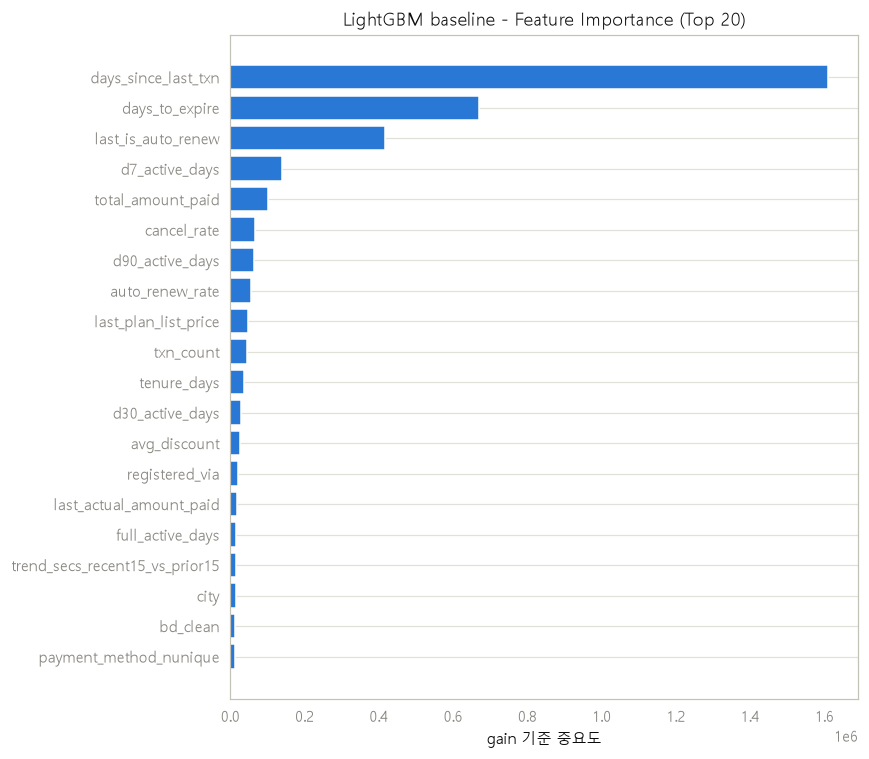

In [6]:
importance = pd.Series(model.feature_importance(importance_type="gain"), index=FEATURE_COLS)
importance = importance.sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(importance.index, importance.values, color=SERIES_1)
ax.set_xlabel("gain 기준 중요도")
ax.set_title("LightGBM baseline - Feature Importance (Top 20)")
ax.grid(axis="x")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [7]:
model.save_model(str(MODELS_DIR / "lightgbm_baseline.txt"))
print(f"저장 완료: {MODELS_DIR / 'lightgbm_baseline.txt'}")

저장 완료: ..\models\lightgbm_baseline.txt
